🔄 Step 1: Generating Imbalanced Loan Default Dataset...
📊 Target Imbalance Status - Non-Defaults (0) vs Defaults (1):
loan_default
1    56
0    44
Name: count, dtype: int64

🔄 Scaling features using StandardScaler (Train only)...
🔄 Injecting SMOTE to balance minority class (Train only)...

🔄 Training Algorithm 1: Logistic Regression...
🔄 Training Algorithm 2: Decision Tree...
🔄 Training Algorithm 3: Random Forest Ensemble...

📈 CRITICAL CLASSIFICATION REPORT FOR RANDOM FOREST:
              precision    recall  f1-score   support

           0       0.50      0.44      0.47         9
           1       0.58      0.64      0.61        11

    accuracy                           0.55        20
   macro avg       0.54      0.54      0.54        20
weighted avg       0.55      0.55      0.55        20


🔄 Generating ROC-AUC Comparison Curves...


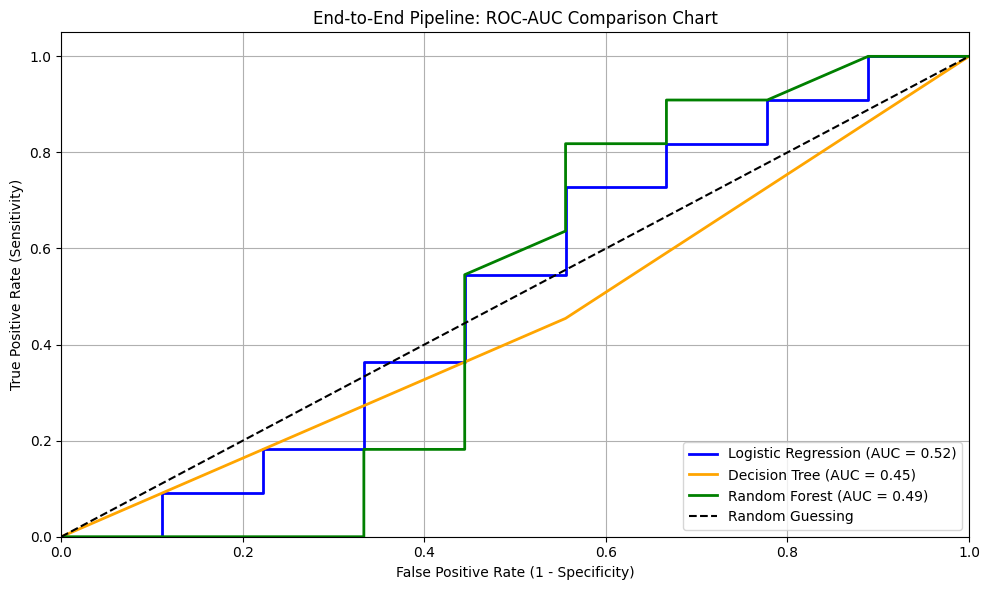


✅ Weekend Project Scaffold Complete! 'winning_loan_model.pkl' exported.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc

from imblearn.over_sampling import SMOTE

# ========================================================
# RULE 1: SET REPRODUCIBILITY SEEDS (Audit Prep)
# ========================================================
# Random seeds explicitly set taakay grading k waqt splits same rahein
np.random.seed(42)

print("🔄 Step 1: Generating Imbalanced Loan Default Dataset...")
# Mock Data: Features (income, credit_score, debt_to_income, age)
mock_data = {
    'income': np.random.normal(55000, 15000, 100),
    'credit_score': np.random.randint(500, 850, 100),
    'debt_to_income': np.random.uniform(0.1, 0.6, 100),
    'age': np.random.randint(21, 65, 100),
    'loan_default': [1 if x < 550 or y > 0.5 else 0 for x, y in zip(np.random.randint(450, 850, 100), np.random.uniform(0.05, 0.7, 100))]
}
df = pd.DataFrame(mock_data)

X = df.drop(columns=['loan_default'])
y = df['loan_default']

print(f"📊 Target Imbalance Status - Non-Defaults (0) vs Defaults (1):\n{y.value_counts()}")

# ========================================================
# RULE 2: STRICT TRAIN-TEST SPLIT (No Leakage Allowed)
# ========================================================
# Split first! Taki scaling ya SMOTE ka koi asar test set par na paray
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ========================================================
# STEP 3: PIPELINE PROCESSING - SCALING & SMOTE INJECTION
# ========================================================
print("\n🔄 Scaling features using StandardScaler (Train only)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Only transforming test, not fitting!

print("🔄 Injecting SMOTE to balance minority class (Train only)...")
smote = SMOTE(k_neighbors=2, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# ========================================================
# STEP 4: TRAINING THREE DIFFERENT ALGORITHMS
# ========================================================
print("\n🔄 Training Algorithm 1: Logistic Regression...")
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

print("🔄 Training Algorithm 2: Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

print("🔄 Training Algorithm 3: Random Forest Ensemble...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# ========================================================
# STEP 5: EMPIRICAL EVALUATION & METRICS INTERROGATION
# ========================================================
print("\n=======================================================")
print("📈 CRITICAL CLASSIFICATION REPORT FOR RANDOM FOREST:")
rf_preds = rf_model.predict(X_test_scaled)
print(classification_report(y_test, rf_preds, zero_division=0))
print("=======================================================")

# ========================================================
# STEP 6: VISUAL COMPARISON VIA ROC-AUC CURVES
# ========================================================
print("\n🔄 Generating ROC-AUC Comparison Curves...")

# Get predicted probabilities for the positive class (1)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
dt_probs = dt_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# Compute Area Under Curve (AUC)
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', color='blue', lw=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})', color='orange', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('End-to-End Pipeline: ROC-AUC Comparison Chart')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Save winning weights
joblib.dump(rf_model, "winning_loan_model.pkl")
print("\n✅ Weekend Project Scaffold Complete! 'winning_loan_model.pkl' exported.")